**install pythob library**

In [1]:
import pandas as pd          # Data handle karne ke liye
import numpy as np           # Math operations
import matplotlib.pyplot as plt  # Graphs banana
from sklearn.linear_model import LinearRegression  # ML model
from sklearn.model_selection import train_test_split  # Data split
from sklearn.metrics import mean_absolute_error    # Accuracy check

**First Step In Machine Learning**

**Upload dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving House_Price_dataset.csv to House_Price_dataset.csv


**Data Visualization**

**Read dataset**

In [3]:
df = pd.read_csv('House_Price_dataset.csv')

**Read First 5 Row**

In [4]:
print(df.head())

   property_id  location_id  \
0       237062         3325   
1       346905         3236   
2       386513          764   
3       656161          340   
4       841645         3226   

                                            page_url property_type     price  \
0  https://www.zameen.com/Property/g_10_g_10_2_gr...          Flat  10000000   
1  https://www.zameen.com/Property/e_11_2_service...          Flat   6900000   
2  https://www.zameen.com/Property/islamabad_g_15...         House  16500000   
3  https://www.zameen.com/Property/islamabad_bani...         House  43500000   
4  https://www.zameen.com/Property/dha_valley_dha...         House   7000000   

      location       city      province_name   latitude  longitude  baths  \
0         G-10  Islamabad  Islamabad Capital  33.679890  73.012640      2   
1         E-11  Islamabad  Islamabad Capital  33.700993  72.971492      3   
2         G-15  Islamabad  Islamabad Capital  33.631486  72.926559      6   
3    Bani Gala  Islamaba

**Read Column list**

In [5]:
print(df.columns.tolist())

['property_id', 'location_id', 'page_url', 'property_type', 'price', 'location', 'city', 'province_name', 'latitude', 'longitude', 'baths', 'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent', 'Area Type', 'Area Size', 'Area Category']


**Row Column Shape**

In [6]:
# Shape dekhen (rows, columns)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 168446, Columns: 20


**Basic Information about dataset**

In [8]:
# Basic info
print(df.info())
print("\n")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  agency         124375 non-null  object 
 16  agent          124374 non-null  object 
 17  Area Type      168446 non-nul

**Data cleaning**

**Missing Value**

In [9]:
# Kitni missing values hain?
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
property_id          0
location_id          0
page_url             0
property_type        0
price                0
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths                0
area                 0
purpose              0
bedrooms             0
date_added           0
agency           44071
agent            44072
Area Type            0
Area Size            0
Area Category        0
dtype: int64


**Feature Engineering **


In [12]:
# 1. Price = 0 wali rows remove karein (fake/incorrect data)
df = df[df['price'] > 0]

# 2. Bedrooms/Baths = 0 wali rows remove karein
df = df[(df['bedrooms'] > 0) & (df['baths'] > 0)]

# 3. Area convert karein (Kanal to Marla)
def convert_to_marla(row):
    if row['Area Type'] == 'Kanal':
        return row['Area Size'] * 20
    else:
        return row['Area Size']

df['area_marla'] = df.apply(convert_to_marla, axis=1)

# 4. Sirf "For Sale" properties rakhein
df = df[df['purpose'] == 'For Sale']

print(f"Clean data rows: {df.shape[0]}")
print(df[['price', 'bedrooms', 'baths', 'area_marla', 'property_type']].head())

Clean data rows: 92767
      price  bedrooms  baths  area_marla property_type
0  10000000         2      2         4.0          Flat
1   6900000         3      3         5.6          Flat
2  16500000         5      6         8.0         House
3  43500000         4      4        40.0         House
4   7000000         3      3         8.0         House


**Feature Selection**

In [13]:
# ML ke liye useful columns select karein
features = ['bedrooms', 'baths', 'area_marla', 'property_type', 'city']
target = 'price'

# Property type aur city ko numbers mein convert karein
df_ml = pd.get_dummies(df[features + [target]],
                        columns=['property_type', 'city'])

print(f"Total features: {df_ml.shape[1]}")
print(df_ml.head())

Total features: 16
   bedrooms  baths  area_marla     price  property_type_Farm House  \
0         2      2         4.0  10000000                     False   
1         3      3         5.6   6900000                     False   
2         5      6         8.0  16500000                     False   
3         4      4        40.0  43500000                     False   
4         3      3         8.0   7000000                     False   

   property_type_Flat  property_type_House  property_type_Lower Portion  \
0                True                False                        False   
1                True                False                        False   
2               False                 True                        False   
3               False                 True                        False   
4               False                 True                        False   

   property_type_Penthouse  property_type_Room  property_type_Upper Portion  \
0                    False    

**model training**

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# X (features) aur y (target) alag karein
X = df_ml.drop('price', axis=1)
y = df_ml['price']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows: {X_test.shape[0]}")

# Model banao aur train karo
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("✅ Model trained!")

Training rows: 74213
Testing rows: 18554
✅ Model trained!


**Model Prediction**

In [15]:
# Predictions karo
y_pred = model.predict(X_test)

# Accuracy check karo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: Rs. {mae:,.0f}")
print(f"R2 Score: {r2:.2f}  (1.0 = perfect, 0.7+ = good)")

Mean Absolute Error: Rs. 6,499,922
R2 Score: 0.79  (1.0 = perfect, 0.7+ = good)


**Model Evaluation **

In [20]:
# Example: Islamabad mein 10 Marla, 5 bed, 3 bath ka ghar
apna_ghar = pd.DataFrame({
    'bedrooms': [5],
    'baths': [3],
    'area_marla': [10],
    'property_type_Farm House': [False],
    'property_type_Flat': [False],
    'property_type_House': [True],
    'property_type_Lower Portion': [False],
    'property_type_Penthouse': [False],
    'property_type_Room': [False],
    'property_type_Upper Portion': [False],
    'city_Faisalabad': [False],
    'city_Islamabad': [True],
    'city_Karachi': [False],
    'city_Lahore': [False],
    'city_Rawalpindi': [False]
})

predicted_price = model.predict(apna_ghar)
print(f"Predicted Price: Rs. {predicted_price[0]:,.0f}")

Predicted Price: Rs. 19,818,557


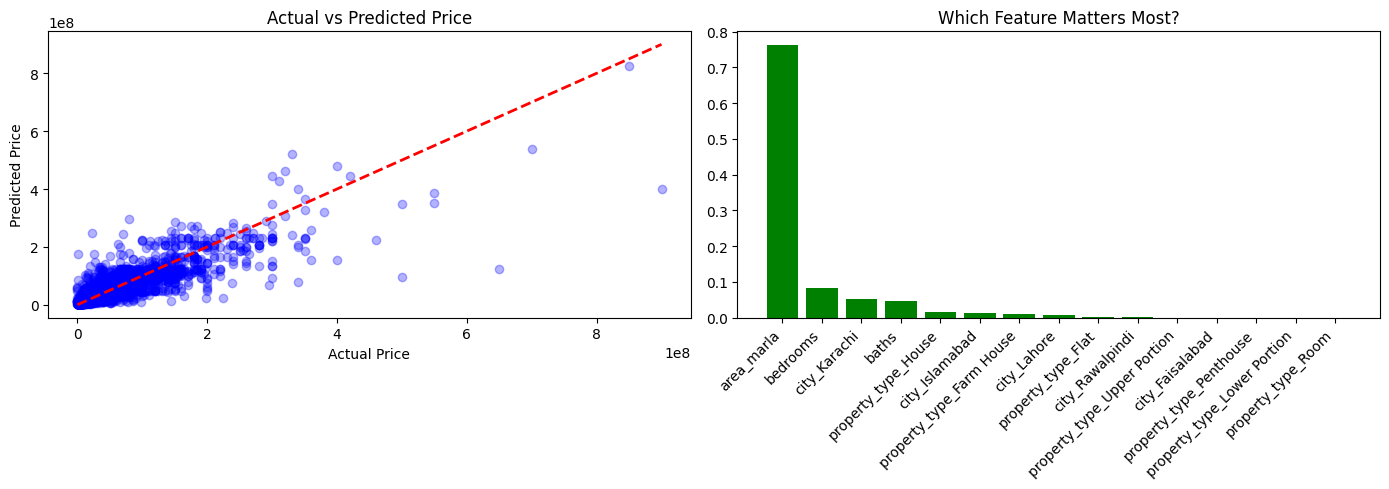

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color='blue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted Price')

# Graph 2: Feature Importance
importances = model.feature_importances_
features_names = X.columns
indices = np.argsort(importances)[::-1]

axes[1].bar(range(len(features_names)),
            importances[indices], color='green')
axes[1].set_xticks(range(len(features_names)))
axes[1].set_xticklabels(features_names[indices], rotation=45, ha='right')
axes[1].set_title('Which Feature Matters Most?')

plt.tight_layout()
plt.savefig('house_price_analysis.png', dpi=150)
plt.show()